# Sprint 7 · Webinar 20 · Sesión Práctica (Preparación de datos + distribuciones + Git)

En esta sesión práctica aplicarás limpieza y descripción estadística usando el dataset `webinar19_customers_latam.csv` (clientes Latam, 5.000 filas) utilizado en la sesión teórica.


## Fecha

02 de Marzo de 2026


## Objetivos de la sesión práctica

Al finalizar la sesión, el/la estudiante podrá:

1. Identificar variables relevantes para un análisis estadístico (enfoque churn y comportamiento).
2. Detectar y tratar valores ausentes e inválidos con reglas simples y justificadas.
3. Convertir y estandarizar tipos de datos (numéricos y fechas) usando funciones de Pandas.
4. Usar bucles (`for`, `while`) e iterables para automatizar validaciones repetitivas.
5. Escribir mini-funciones de limpieza reutilizables y bien documentadas.
6. Describir distribuciones numéricas y categóricas (estadísticas + visualizaciones) e interpretar significado de negocio.
7. Crear un repositorio, clonarlo localmente y realizar el primer commit (flujo mínimo Git/GitHub).


## Preparación del entorno

Carga librerías y el dataset base. Este dataset tiene columnas "raw" con problemas intencionales para practicar:
- `monthly_fee_raw` con textos como `"N/A"` / `"unknown"`.
- `last_activity_raw` con fechas inválidas o vacías.
- edades fuera de rango (`age`).
- `total_spend_90d_usd` negativo en algunos casos.
- `country` / `city` vacíos o inconsistentes.

Objetivo: convertir esto en un dataset **listo para análisis estadístico**.


In [1]:
# Librerías base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 50)

DATA_PATH = "webinar19_customers_latam.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (5000, 20)


,customer_id,country,city,segment,signup_date,last_activity_date,device_os,plan_type,monthly_fee_usd,orders_90d,avg_order_value_usd,total_spend_90d_usd,support_tickets_90d,satisfaction_score,coupon_used,preferred_category,churned,age,monthly_fee_raw,last_activity_raw
0,C000001,México,CDMX,Retail,2024-08-23,2025-08-07,macOS,Basic,30.76,4,24.42,97.69,1,4.0,yes,Moda,0,27.0,30.76,2025-08-07
1,C000002,Argentina,Mendoza,SMB,2025-06-22,2025-12-26,iOS,Pro,65.80,6,26.20,157.18,2,4.3,yes,Moda,0,26.0,65.8,2025-12-26
2,C000003,Colombia,Medellín,Retail,2024-09-02,2024-12-02,Android,Plus,49.18,2,22.13,44.25,0,4.2,yes,Alimentos,1,27.0,49.18,2024-12-02
3,C000004,Colombia,Barranquilla,SMB,2025-11-01,2025-12-28,Linux,Basic,15.66,7,30.46,213.23,0,3.4,no,Hogar,0,45.0,15.66,2025-12-28
4,C000005,Colombia,Bogotá,Retail,2024-12-29,2025-09-20,Windows,Plus,NaN,4,38.71,154.85,0,4.1,yes,Belleza,0,45.0,NaN,2025-09-20


## Ejercicio 0

**Contexto:** queremos entender churn (columna `churned`: 1 = churn, 0 = activo).


1. ¿Qué columnas parecen más relevantes para explicar churn?.
2. Muestra un `df[cols].head()` con esas columnas.
3. Calcula el porcentaje de valores faltantes (`NaN`) por columna y muestra el top.

### Pistas
- Usa `df.info()` para ver tipos.
- Usa `df.isna().mean()` para proporciones.
- Piensa en variables de comportamiento: compras, tickets, satisfacción, actividad, plan.


#### Solución:


In [ ]:
# SOLUCIÓN (Ejercicio 0)

# 1) Selección razonable de variables para churn (puede variar, aquí un ejemplo)
cols_relevantes = [
    "churned",
    "support_tickets_90d",
    "satisfaction_score",
    "total_spend_90d_usd",
    "orders_90d",
    "plan_type",
    "last_activity_raw"  # útil para crear 'days_since_last_activity'
]

display(df[cols_relevantes].head())

# 2) Valores faltantes (proporción)
missing = df.isna().mean().sort_values(ascending=False)
display(missing.head(8))


,churned,support_tickets_90d,satisfaction_score,total_spend_90d_usd,orders_90d,plan_type,last_activity_raw
0,0,1,4.0,97.69,4,Basic,2025-08-07
1,0,2,4.3,157.18,6,Pro,2025-12-26
2,1,0,4.2,44.25,2,Plus,2024-12-02
3,0,0,3.4,213.23,7,Basic,2025-12-28
4,0,0,4.1,154.85,4,Plus,2025-09-20


,0
age,0.0592
monthly_fee_raw,0.0338
monthly_fee_usd,0.0300
country,0.0100
city,0.0100
last_activity_raw,0.0026
segment,0.0000
customer_id,0.0000


## Ejercicio 1 · Identificando variables relevantes (7.1.1) y validación estructural

### Objetivo
- Identificar columnas numéricas/categóricas/fechas.
- Encontrar columnas candidatas para análisis de churn y calidad de datos.

### Pistas
- Usa `df.select_dtypes(...)` para separar numéricas y categóricas.
- Revisa cardinalidad con `nunique()`.
- Haz un resumen rápido con `describe()` para numéricas.


#### Solución:


In [ ]:
# SOLUCIÓN (Ejercicio 1)

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# Cardinalidad para categóricas (útil para entender si hay demasiadas categorías)
card = df[cat_cols].nunique(dropna=False).sort_values(ascending=False)
display(card.head(10))

# Resumen numérico
display(df[num_cols].describe().T)


Numéricas: ['monthly_fee_usd', 'orders_90d', 'avg_order_value_usd', 'total_spend_90d_usd', 'support_tickets_90d', 'satisfaction_score', 'churned', 'age']
Categóricas: ['customer_id', 'country', 'city', 'segment', 'signup_date', 'last_activity_date', 'device_os', 'plan_type', 'coupon_used', 'preferred_category', 'monthly_fee_raw', 'last_activity_raw']


,0
customer_id,5000
monthly_fee_raw,3154
last_activity_date,999
last_activity_raw,999
signup_date,699
city,24
preferred_category,7
country,6
device_os,5
plan_type,4


,count,mean,std,min,25%,50%,75%,max
monthly_fee_usd,4850.0,45.145140,34.012812,-10.00,24.9300,34.875,51.800,191.86
orders_90d,5000.0,4.379400,3.020742,0.00,2.0000,4.000,6.000,23.00
avg_order_value_usd,5000.0,31.830598,19.114518,3.80,18.8600,27.200,39.465,233.53
total_spend_90d_usd,5000.0,136.339096,140.361732,-607.51,53.6375,99.540,176.775,3505.99
support_tickets_90d,5000.0,0.654200,0.802715,0.00,0.0000,0.000,1.000,6.00
satisfaction_score,5000.0,4.081060,0.566981,1.90,3.7000,4.100,4.500,5.00
churned,5000.0,0.511600,0.499915,0.00,0.0000,1.000,1.000,1.00
age,4704.0,35.914753,63.595603,-5.00,26.0000,32.000,38.000,999.00


## Ejercicio 2 · Valores ausentes o inválidos (7.1.2)

### Objetivo
Detectar y cuantificar:
- edades inválidas (`age` <= 0 o > 100)
- gasto negativo (`total_spend_90d_usd` < 0)
- `country` / `city` vacíos
- fechas inválidas en `last_activity_raw`

Luego, aplicar una estrategia simple:
- inválidos -> `NaN` (o `NaT` para fechas)  
- imputar edad con mediana  
- reemplazar texto vacío con `"Unknown"`

### Pistas
- `pd.to_datetime(..., errors="coerce")` produce `NaT` si no puede parsear.
- `Series.mask(cond, np.nan)` reemplaza donde la condición es True.
- Para texto: `fillna("").str.strip().replace("", "Unknown")`


#### Solución:


In [ ]:
# SOLUCIÓN (Ejercicio 2)

df_clean = df.copy()

# 1) Máscaras de inválidos
age_invalid = df_clean["age"].isna() | (df_clean["age"] <= 0) | (df_clean["age"] > 100)
spend_invalid = df_clean["total_spend_90d_usd"] < 0

country_empty = df_clean["country"].fillna("").astype(str).str.strip().eq("")
city_empty = df_clean["city"].fillna("").astype(str).str.strip().eq("")

print("Edad inválida o faltante:", age_invalid.mean().round(3))
print("Gasto negativo:", spend_invalid.mean().round(3))
print("Country vacío:", country_empty.mean().round(3))
print("City vacío:", city_empty.mean().round(3))

# 2) Fechas: string -> datetime
df_clean["last_activity_clean"] = pd.to_datetime(df_clean["last_activity_raw"], errors="coerce")

# 3) Limpieza de edad
df_clean["age"] = pd.to_numeric(df_clean["age"], errors="coerce")
df_clean.loc[(df_clean["age"] <= 0) | (df_clean["age"] > 100), "age"] = np.nan
df_clean["age_clean"] = df_clean["age"].fillna(df_clean["age"].median())

# 4) Limpieza de gasto
df_clean["spend_clean"] = df_clean["total_spend_90d_usd"].mask(df_clean["total_spend_90d_usd"] < 0, np.nan)

# 5) País y ciudad
for col in ["country", "city"]:
    df_clean[col] = df_clean[col].fillna("").astype(str).str.strip()
    df_clean[col] = df_clean[col].replace("", "Unknown").str.title()

display(df_clean[["age", "age_clean", "total_spend_90d_usd", "spend_clean", "country", "city", "last_activity_raw", "last_activity_clean"]].head(10))


Edad inválida o faltante: 0.071
Gasto negativo: 0.006
Country vacío: 0.01
City vacío: 0.01


,age,age_clean,total_spend_90d_usd,spend_clean,country,city,last_activity_raw,last_activity_clean
0,27.0,27.0,97.69,97.69,México,Cdmx,2025-08-07,2025-08-07
1,26.0,26.0,157.18,157.18,Argentina,Mendoza,2025-12-26,2025-12-26
2,27.0,27.0,44.25,44.25,Colombia,Medellín,2024-12-02,2024-12-02
3,45.0,45.0,213.23,213.23,Colombia,Barranquilla,2025-12-28,2025-12-28
4,45.0,45.0,154.85,154.85,Colombia,Bogotá,2025-09-20,2025-09-20
5,28.0,28.0,156.20,156.20,Perú,Trujillo,2026-07-17,2026-07-17
6,37.0,37.0,26.91,26.91,Perú,Arequipa,2025-02-18,2025-02-18
7,NaN,32.0,389.20,389.20,México,Cdmx,2026-04-19,2026-04-19
8,44.0,44.0,220.63,220.63,Colombia,Bogotá,2025-11-19,2025-11-19
9,46.0,46.0,188.13,188.13,Argentina,Córdoba,2025-12-17,2025-12-17


## Ejercicio 3 · Funciones de Python/Pandas para automatizar limpieza (7.1.3)

### Objetivo
- Convertir `monthly_fee_raw` a numérico usando `pd.to_numeric`.
- Crear `monthly_fee_clean` imputando faltantes por **mediana por plan_type**.

### Pistas
- `pd.to_numeric(..., errors="coerce")` convierte textos inválidos a `NaN`.
- `groupby("plan_type")["col"].transform("median")` permite imputar por grupo.


#### Solución:


In [ ]:
# SOLUCIÓN (Ejercicio 3)

df_clean["monthly_fee_num"] = pd.to_numeric(df_clean["monthly_fee_raw"], errors="coerce")

group_median = df_clean.groupby("plan_type")["monthly_fee_num"].transform("median")
df_clean["monthly_fee_clean"] = df_clean["monthly_fee_num"].fillna(group_median)

print("NaN en monthly_fee_clean:", df_clean["monthly_fee_clean"].isna().sum())
display(df_clean[["plan_type","monthly_fee_raw","monthly_fee_num","monthly_fee_clean"]].head(12))


NaN en monthly_fee_clean: 0


,plan_type,monthly_fee_raw,monthly_fee_num,monthly_fee_clean
0,Basic,30.76,30.76,30.76
1,Pro,65.8,65.80,65.80
2,Plus,49.18,49.18,49.18
3,Basic,15.66,15.66,15.66
4,Plus,NaN,NaN,44.92
5,Plus,45.53,45.53,45.53
6,Basic,23.89,23.89,23.89
7,Plus,50.65,50.65,50.65
8,Plus,47.07,47.07,47.07
9,Basic,36.58,36.58,36.58


## Ejercicio 4 · Bucles (for/while) e iterables (7.1.4)

### Objetivo
Crear una tabla de “calidad” por columna (para varias columnas) usando un `for`:

Para cada columna en una lista, calcula:
- porcentaje de faltantes
- mínimo y máximo (si es numérica)
- número de valores únicos (si es categórica)

### Pistas
- Crea una lista `cols_check`.
- Usa `df_clean[col].dtype` o `pd.api.types.is_numeric_dtype(...)`.
- Guarda resultados en una lista de diccionarios y luego `pd.DataFrame(...)`.


In [ ]:
# si condicion se cumple:
#   realiza todo lo que esta aqui
# entonces:
#   realiza esto

edad = 80

if edad<100:
  print("es una edada valida")
else:
  print("Edad invalidad")

es una edada valida


#### Solución:


In [ ]:
# SOLUCIÓN (Ejercicio 4)

# funcion para verificar si un tipo de dato es numérico (como int, float, etc.)
from pandas.api.types import is_numeric_dtype

cols_check = ["age_clean", "monthly_fee_clean", "orders_90d", "spend_clean", "country", "plan_type"]

results = []
for col in cols_check:
    row = {"column": col, "missing_rate": float(df_clean[col].isna().mean())}
    if is_numeric_dtype(df_clean[col]):
        row["min"] = float(df_clean[col].min(skipna=True))
        row["max"] = float(df_clean[col].max(skipna=True))
        row["nunique"] = int(df_clean[col].nunique(dropna=True))
    else:
        row["min"] = None
        row["max"] = None
        row["nunique"] = int(df_clean[col].nunique(dropna=False))
    results.append(row)

quality_df = pd.DataFrame(results).sort_values("missing_rate", ascending=False)
display(quality_df)


,column,missing_rate,min,max,nunique
3,spend_clean,0.0058,0.0,3505.99,4403
0,age_clean,0.0000,16.0,65.00,47
1,monthly_fee_clean,0.0000,-10.0,191.86,3154
2,orders_90d,0.0000,0.0,23.00,23
4,country,0.0000,NaN,NaN,6
5,plan_type,0.0000,NaN,NaN,4


## Ejercicio 5 · Mini-funciones de limpieza (7.1.5)

### Objetivo
Escribe 2 mini-funciones:

1) `compute_days_since_last_activity(df, ref_date)`  
- Convierte `last_activity_clean` (si no existe, créala a partir de `last_activity_raw`).
- Crea columna `days_since_last_activity` respecto a `ref_date` (por defecto `"2025-12-01"`).
- Si la fecha es inválida (`NaT`), deja `NaN`.

2) `flag_high_risk_customers(df)`  
- Crea una columna `risk_flag` (0/1) con una regla simple:
  - `support_tickets_90d >= 3` **y**
  - `satisfaction_score <= 3.5` **y**
  - `days_since_last_activity >= 60`

### Pistas
- `pd.to_datetime(..., errors="coerce")`
- `(ref_date - series).dt.days` para días.
- Documenta la función con un docstring corto.


#### Solución:


In [ ]:
# SOLUCIÓN (Ejercicio 5)

def compute_days_since_last_activity(df_in: pd.DataFrame, ref_date: str = "2025-12-01") -> pd.DataFrame:
    """Crea 'days_since_last_activity' a partir de una fecha de referencia.

    Parámetros
    ----------
    df_in : pd.DataFrame
        DataFrame de entrada.
    ref_date : str
        Fecha de referencia en formato YYYY-MM-DD.

    Retorna
    -------
    pd.DataFrame
        Copia del DataFrame con una columna nueva:
        - days_since_last_activity (float, porque puede tener NaN)
    """
    out = df_in.copy()
    if "last_activity_clean" not in out.columns:
        out["last_activity_clean"] = pd.to_datetime(out["last_activity_raw"], errors="coerce")

    ref = pd.to_datetime(ref_date)
    out["days_since_last_activity"] = (ref - out["last_activity_clean"]).dt.days
    return out


def flag_high_risk_customers(df_in: pd.DataFrame) -> pd.DataFrame:
    """Crea un flag simple de riesgo (0/1) basado en reglas de negocio.

    Regla (ejemplo para práctica):
    - tickets >= 3 y satisfacción <= 3.5 y días sin actividad >= 60.
    """
    out = df_in.copy()

    mask = (
        (out["support_tickets_90d"] >= 3) &
        (out["satisfaction_score"] <= 3.5) &
        (out["days_since_last_activity"] >= 60)
    )
    out["risk_flag"] = mask.astype(int)
    return out


df_enriched = compute_days_since_last_activity(df_clean)
df_enriched = flag_high_risk_customers(df_enriched)

display(df_enriched[["last_activity_raw","last_activity_clean","days_since_last_activity",
                     "support_tickets_90d","satisfaction_score","risk_flag"]].head(12))

print("Proporción de clientes con risk_flag=1:", df_enriched["risk_flag"].mean().round(3))


,last_activity_raw,last_activity_clean,days_since_last_activity,support_tickets_90d,satisfaction_score,risk_flag
0,2025-08-07,2025-08-07,116.0,1,4.0,0
1,2025-12-26,2025-12-26,-25.0,2,4.3,0
2,2024-12-02,2024-12-02,364.0,0,4.2,0
3,2025-12-28,2025-12-28,-27.0,0,3.4,0
4,2025-09-20,2025-09-20,72.0,0,4.1,0
5,2026-07-17,2026-07-17,-228.0,0,4.5,0
6,2025-02-18,2025-02-18,286.0,1,3.7,0
7,2026-04-19,2026-04-19,-139.0,0,4.8,0
8,2025-11-19,2025-11-19,12.0,1,3.4,0
9,2025-12-17,2025-12-17,-16.0,1,4.1,0


Proporción de clientes con risk_flag=1: 0.002


## Ejercicio 6 · Distribuciones: estadística + visualización + negocio (7.2)

### Objetivo
1) Calcular estadísticas numéricas para:
- `spend_clean`, `orders_90d`, `support_tickets_90d`, `satisfaction_score`, `monthly_fee_clean`

2) Calcular frecuencias para:
- `plan_type`, `segment`, `country`

3) Graficar:
- Histograma de `spend_clean`
- Boxplot de `spend_clean` por `plan_type`

4) Interpretación rápida (negocio):
- ¿Qué sugiere la forma de la distribución del gasto?
- ¿Qué plan parece tener mayor variabilidad?

### Pistas
- Numéricas: `describe(percentiles=[...]).T`
- Categóricas: `value_counts(normalize=True)`
- Histogramas: `plt.hist(...)`
- Boxplot por grupos: arma una lista de series y pásala a `plt.boxplot(...)`


#### Solución:


,count,mean,std,min,25%,50%,75%,90%,95%,max
spend_clean,4971.0,138.033607,138.670864,0.0,54.495,100.19,177.46,287.270,384.505,3505.99
orders_90d,5000.0,4.379400,3.020742,0.0,2.000,4.00,6.00,8.000,10.000,23.00
support_tickets_90d,5000.0,0.654200,0.802715,0.0,0.000,0.00,1.00,2.000,2.000,6.00
satisfaction_score,5000.0,4.081060,0.566981,1.9,3.700,4.10,4.50,4.900,5.000,5.00
monthly_fee_clean,5000.0,45.209198,34.015625,-10.0,25.035,35.01,51.80,72.051,78.257,191.86


,count,proportion
plan_type,,
Basic,2514,0.503
Plus,1364,0.273
Pro,897,0.179
Enterprise,225,0.045


,count,proportion
segment,,
Retail,3456,0.691
SMB,1297,0.259
Enterprise,247,0.049


,count,proportion
country,,
Colombia,1734,0.347
México,1097,0.219
Perú,771,0.154
Argentina,751,0.150
Chile,597,0.119
Unknown,50,0.010


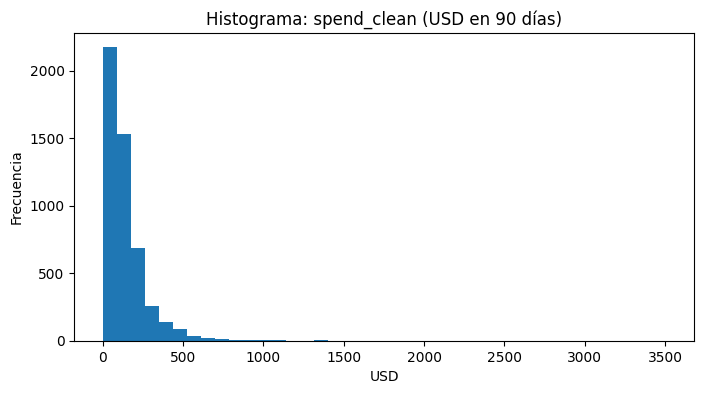

/tmp/ipython-input-3281009026.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


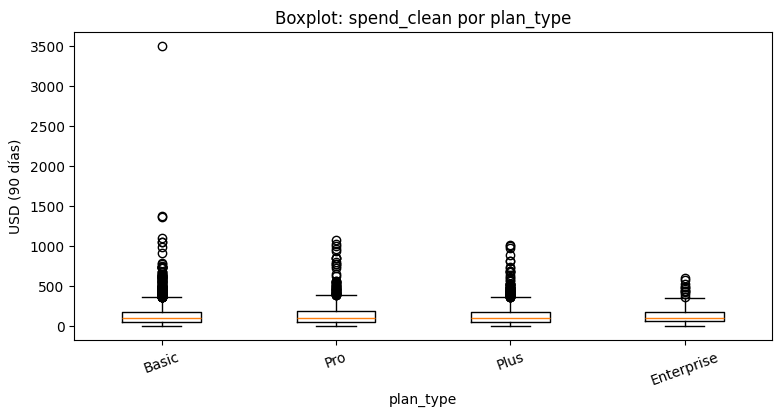

Interpretación (ejemplo): Si el histograma es sesgado a la derecha, pocos clientes concentran gran gasto.
Interpretación (ejemplo): Un boxplot con caja/bigotes más largos indica mayor variabilidad en el gasto.


In [ ]:
# SOLUCIÓN (Ejercicio 6)

metrics = ["spend_clean", "orders_90d", "support_tickets_90d", "satisfaction_score", "monthly_fee_clean"]
display(df_enriched[metrics].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T)

for col in ["plan_type", "segment", "country"]:
    freq = df_enriched[col].value_counts(dropna=False)
    prop = (freq / len(df_enriched)).round(3)
    display(pd.DataFrame({"count": freq, "proportion": prop}))

# Histograma de spend
plt.figure(figsize=(8,4))
plt.hist(df_enriched["spend_clean"].dropna(), bins=40)
plt.title("Histograma: spend_clean (USD en 90 días)")
plt.xlabel("USD")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot spend por plan
plt.figure(figsize=(9,4))
groups = []
labels = []
for p in df_enriched["plan_type"].unique():
    groups.append(df_enriched.loc[df_enriched["plan_type"] == p, "spend_clean"].dropna())
    labels.append(p)

plt.boxplot(groups, labels=labels, showfliers=True)
plt.title("Boxplot: spend_clean por plan_type")
plt.xlabel("plan_type")
plt.ylabel("USD (90 días)")
plt.xticks(rotation=20)
plt.show()

# Interpretación rápida (ejemplo)
print("Interpretación (ejemplo): Si el histograma es sesgado a la derecha, pocos clientes concentran gran gasto.")
print("Interpretación (ejemplo): Un boxplot con caja/bigotes más largos indica mayor variabilidad en el gasto.")


## Ejercicio 7 · Git/GitHub: crear repo, clonar, primer commit (8) (5 min)

### Objetivo
Realizar el flujo mínimo de versionamiento para este webinar.

### Checklist (paso a paso)

1. Crear repositorio en GitHub  
   - Nombre sugerido: `sprint5-webinar20-practico`
   - Añade un `README.md` (opcional, recomendado)

2. Clonar en tu computador:
```bash
git clone <URL_DEL_REPO>
cd sprint5-webinar20-practico
```

3. Copiar dentro del repo:
- `Sprint5_Webinar20_Practico.ipynb`
- `webinar19_customers_latam.csv` (o una versión ligera si pesa mucho)

4. Primer commit:
```bash
git add .
git commit -m "Webinar 20: práctica de limpieza y distribuciones"
git push
```

### Pistas comunes
- Si te pide credenciales en HTTPS, usa el método recomendado por GitHub (token personal) o configura SSH (lo veremos con detalle después).
- Verifica instalación:
```bash
git --version
```


## Take aways (resumen extendido)

1. La selección de variables parte de una **pregunta de negocio** (aquí: churn) y se valida con estructura y calidad.
2. Valores faltantes e inválidos no se “tapan” sin pensar: se detectan, cuantifican y se decide una estrategia (eliminar, imputar, marcar).
3. Convertir tipos correctamente (`to_numeric`, `to_datetime`) evita errores silenciosos y acelera el análisis.
4. Los bucles ayudan a automatizar controles repetitivos; para datos grandes, complementa con operaciones vectorizadas.
5. Mini-funciones documentadas son el primer paso hacia pipelines de datos reproducibles.
6. Distribuciones y gráficos convierten números en decisiones: segmentación, foco de soporte, prevención de churn.
7. Git/GitHub te permite trabajar con historial, colaboración y mejores prácticas profesionales desde el inicio.


## Cierre


**Reflexión:**
- ¿Qué ventaja tiene convertir tu trabajo en un proyecto usando funciones y Git en lugar de código suelto?
- ¿Qué te reveló el histograma sobre tus datos hoy?



## Siguientes Pasos
- **Próxima sesión:** Sprint 7 - Segmentación y Outliers profundos.
- **Participación:** Sube tu primer repositorio de práctica a GitHub.
- **Recordatorios:** No temas a la terminal; es tu amiga.
